# 11 — Tuning & Optimization

**Goal:** Hyperparameter-tune 10 models from stages 06–10 under the unchanged fair protocol.

**Execution:**
- **Pass A (fast):** Ridge, Polynomial, Spline, Huber, ExtraTrees — ~1 hour total.
- **Pass B (expensive):** LightGBM, CatBoost, HistGradientBoosting, TabNet, MLP-medium — ~7 hours total.

**Protocol (unchanged from 06–10):**
- 5-fold rolling temporal validation. Training = `train_range ∩ fair_subset` (~395k rows). Validation = full untouched val slice.
- Fresh `RobustScaler` per fold. SEED = 42.
- Early stopping (Pass B iterative models): last 15% of training data as internal eval set. Val fold never used for early stopping.
- Best config per model: highest mean R² pooled across folds and targets.

In [1]:
import warnings
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

from sklearn.preprocessing import RobustScaler, PolynomialFeatures, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning
import lightgbm as lgb
from catboost import CatBoostRegressor
from pytorch_tabnet.tab_model import TabNetRegressor

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

SEED = 42
np.random.seed(SEED)

DATA_PATH   = Path('../data/processed/ethylene_methane.parquet')
SPLITS_PATH = Path('../results/tables/validation_splits.parquet')
SUBSET_PATH = Path('../data/subsets/fair_subset_indices.parquet')
MODEL_DIR   = Path('../results/models/tuned_11')
TABLES_DIR  = Path('../results/tables')
FIG_DIR     = Path('../results/figures')
MEMO_PATH   = Path('../results/memos/11_tuning_optimization.md')

for d in (MODEL_DIR, TABLES_DIR, FIG_DIR, MEMO_PATH.parent):
    d.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

## 1. Load Data & Pre-compute Folds

In [2]:
df = pd.read_parquet(DATA_PATH, columns=SENSORS + TARGETS)
splits_df = pd.read_parquet(SPLITS_PATH)
subset_idx = pd.read_parquet(SUBSET_PATH)['row_idx'].to_numpy()
assert (np.diff(subset_idx) >= 0).all(), 'Subset indices not monotonic'

fold_ids = sorted(int(f) for f in splits_df['fold'].unique())

def prepare_fold(fold_id):
    tr = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'train')].iloc[0]
    va = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'val')].iloc[0]
    train_idx = subset_idx[(subset_idx >= tr['start_idx']) & (subset_idx < tr['end_idx'])]
    val_idx = np.arange(va['start_idx'], va['end_idx'])
    X_tr = df[SENSORS].iloc[train_idx].to_numpy()
    y_tr = df[TARGETS].iloc[train_idx].to_numpy()
    X_va = df[SENSORS].iloc[val_idx].to_numpy()
    y_va = df[TARGETS].iloc[val_idx].to_numpy()
    scaler = RobustScaler().fit(X_tr)
    return scaler.transform(X_tr), y_tr, scaler.transform(X_va), y_va, scaler

folds_data = {}
for fid in fold_ids:
    folds_data[fid] = prepare_fold(fid)
    print(f'Fold {fid}: train={folds_data[fid][0].shape}, val={folds_data[fid][2].shape}')

print(f'\nDataset: {len(df):,} rows | Subset: {len(subset_idx):,} | Folds: {len(fold_ids)}')

Fold 1: train=(398670, 16), val=(407367, 16)
Fold 2: train=(391532, 16), val=(419449, 16)
Fold 3: train=(392782, 16), val=(407362, 16)
Fold 4: train=(392275, 16), val=(431972, 16)
Fold 5: train=(399678, 16), val=(435098, 16)

Dataset: 4,178,504 rows | Subset: 1,000,000 | Folds: 5


## 2. Tuning Utilities

In [3]:
all_search = []
best_metrics = []
best_configs = {}
fold1_preds = {}

def record_metrics(records, model_name, cfg_id, cfg_str,
                   fold_id, y_va, y_pred, elapsed):
    r2s = []
    for t_idx, target in enumerate(TARGETS):
        r2 = float(r2_score(y_va[:, t_idx], y_pred[:, t_idx]))
        r2s.append(r2)
        records.append({
            'model': model_name, 'config_id': cfg_id, 'config': cfg_str,
            'fold': fold_id, 'target': target,
            'mae': float(mean_absolute_error(y_va[:, t_idx], y_pred[:, t_idx])),
            'rmse': float(np.sqrt(mean_squared_error(y_va[:, t_idx], y_pred[:, t_idx]))),
            'r2': r2, 'seconds': elapsed,
        })
    return r2s

def finish_tuning(model_name, local_records, configs):
    local_df = pd.DataFrame(local_records)
    all_search.extend(local_records)
    cfg_scores = local_df.groupby('config_id')['r2'].mean().sort_values(ascending=False)
    best_id = cfg_scores.index[0]
    best_r2 = cfg_scores.iloc[0]
    best_cfg = configs[best_id]
    best_configs[model_name] = best_cfg
    best_fold = local_df[local_df['config_id'] == best_id].drop(
        columns=['config_id', 'config', 'seconds'])
    best_metrics.extend(best_fold.to_dict('records'))
    print(f'\n  Best config: {best_cfg}')
    print(f'  Best mean R2: {best_r2:.4f}')
    for target in TARGETS:
        t_rows = best_fold[best_fold['target'] == target]
        print(f'    {target}: R2={t_rows["r2"].mean():.4f} +/- {t_rows["r2"].std():.4f}')
    return local_df, best_id, best_cfg

def early_stop_split(X, y, frac=0.15):
    n = int(len(X) * (1 - frac))
    return X[:n], y[:n], X[n:], y[n:]

print('Utilities ready.')

Utilities ready.


## Pass A — Fast Models

Ridge, Polynomial, Spline, Huber, ExtraTrees.
Estimated ~1 hour total.

In [4]:
print('=== Ridge (grid, 7 configs) ===')
ridge_configs = [{'alpha': a} for a in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]]
ridge_records = []
t0_model = time.perf_counter()

for cfg_id, cfg in enumerate(ridge_configs):
    cfg_r2s = []
    for fold_id in fold_ids:
        X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
        model = Ridge(alpha=cfg['alpha'], random_state=SEED)
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)
        elapsed = time.perf_counter() - t0
        r2s = record_metrics(ridge_records, 'ridge_tuned', cfg_id,
                             str(cfg), fold_id, y_va, y_pred, elapsed)
        cfg_r2s.extend(r2s)
    print(f'  [{cfg_id+1}/{len(ridge_configs)}] alpha={cfg["alpha"]:<8} '
          f'R2={np.mean(cfg_r2s):.4f}')

ridge_df, ridge_best_id, ridge_best_cfg = finish_tuning(
    'ridge_tuned', ridge_records, ridge_configs)

for fold_id in fold_ids:
    X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
    model = Ridge(alpha=ridge_best_cfg['alpha'], random_state=SEED)
    model.fit(X_tr, y_tr)
    joblib.dump({'model': model, 'scaler': scaler, 'fold': fold_id,
                 'name': 'ridge_tuned', 'config': ridge_best_cfg},
                MODEL_DIR / f'fold_{fold_id}_ridge_tuned.joblib')
    if fold_id == 1:
        fold1_preds['ridge_tuned'] = (y_va.copy(), model.predict(X_va))

print(f'Total: {time.perf_counter() - t0_model:.0f}s')

=== Ridge (grid, 7 configs) ===
  [1/7] alpha=0.001    R2=0.6047
  [2/7] alpha=0.01     R2=0.6047
  [3/7] alpha=0.1      R2=0.6047
  [4/7] alpha=1.0      R2=0.6049
  [5/7] alpha=10.0     R2=0.6026
  [6/7] alpha=100.0    R2=0.5881
  [7/7] alpha=1000.0   R2=0.5623

  Best config: {'alpha': 1.0}
  Best mean R2: 0.6049
    methane_ppm: R2=0.6310 +/- 0.0449
    ethylene_ppm: R2=0.5787 +/- 0.0882
Total: 4s


In [5]:
print('=== Polynomial Regression (grid, 20 configs) ===')
poly_configs = [
    {'degree': d, 'interaction_only': io, 'ridge_alpha': a}
    for d in [2, 3] for io in [False, True]
    for a in [0.01, 0.1, 1.0, 10.0, 100.0]
]
poly_records = []
t0_model = time.perf_counter()

for cfg_id, cfg in enumerate(poly_configs):
    cfg_r2s = []
    for fold_id in fold_ids:
        X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
        model = Pipeline([
            ('poly', PolynomialFeatures(
                degree=cfg['degree'],
                interaction_only=cfg['interaction_only'],
                include_bias=False)),
            ('ridge', Ridge(alpha=cfg['ridge_alpha'], random_state=SEED)),
        ])
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)
        elapsed = time.perf_counter() - t0
        r2s = record_metrics(poly_records, 'poly_tuned', cfg_id,
                             str(cfg), fold_id, y_va, y_pred, elapsed)
        cfg_r2s.extend(r2s)
    print(f'  [{cfg_id+1}/{len(poly_configs)}] d={cfg["degree"]} '
          f'io={str(cfg["interaction_only"]):<5} '
          f'a={cfg["ridge_alpha"]:<6} R2={np.mean(cfg_r2s):.4f}')

poly_df, poly_best_id, poly_best_cfg = finish_tuning(
    'poly_tuned', poly_records, poly_configs)

for fold_id in fold_ids:
    X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
    model = Pipeline([
        ('poly', PolynomialFeatures(
            degree=poly_best_cfg['degree'],
            interaction_only=poly_best_cfg['interaction_only'],
            include_bias=False)),
        ('ridge', Ridge(alpha=poly_best_cfg['ridge_alpha'], random_state=SEED)),
    ])
    model.fit(X_tr, y_tr)
    joblib.dump({'model': model, 'scaler': scaler, 'fold': fold_id,
                 'name': 'poly_tuned', 'config': poly_best_cfg},
                MODEL_DIR / f'fold_{fold_id}_poly_tuned.joblib')
    if fold_id == 1:
        fold1_preds['poly_tuned'] = (y_va.copy(), model.predict(X_va))

print(f'Total: {time.perf_counter() - t0_model:.0f}s')

=== Polynomial Regression (grid, 20 configs) ===
  [1/20] d=2 io=False a=0.01   R2=0.6028
  [2/20] d=2 io=False a=0.1    R2=0.6041
  [3/20] d=2 io=False a=1.0    R2=0.6052
  [4/20] d=2 io=False a=10.0   R2=0.6065
  [5/20] d=2 io=False a=100.0  R2=0.6044
  [6/20] d=2 io=True  a=0.01   R2=0.6013
  [7/20] d=2 io=True  a=0.1    R2=0.6042
  [8/20] d=2 io=True  a=1.0    R2=0.6060
  [9/20] d=2 io=True  a=10.0   R2=0.6070
  [10/20] d=2 io=True  a=100.0  R2=0.5993


c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.588970773015971e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.8112212210191642e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.174125851581017e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


  [11/20] d=3 io=False a=0.01   R2=-71.1602


c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.0772873059478694e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.7539167032520475e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.298842405605518e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


  [12/20] d=3 io=False a=0.1    R2=-97.6533
  [13/20] d=3 io=False a=1.0    R2=-127.6693
  [14/20] d=3 io=False a=10.0   R2=-125.4848
  [15/20] d=3 io=False a=100.0  R2=-58.8571
  [16/20] d=3 io=True  a=0.01   R2=0.2526
  [17/20] d=3 io=True  a=0.1    R2=0.2803
  [18/20] d=3 io=True  a=1.0    R2=0.3403
  [19/20] d=3 io=True  a=10.0   R2=0.4392
  [20/20] d=3 io=True  a=100.0  R2=0.4818

  Best config: {'degree': 2, 'interaction_only': True, 'ridge_alpha': 10.0}
  Best mean R2: 0.6070
    methane_ppm: R2=0.6539 +/- 0.0498
    ethylene_ppm: R2=0.5601 +/- 0.0597
Total: 1263s


In [6]:
print('=== Spline Regression (grid, 50 configs) ===')
spline_configs = [
    {'n_knots': k, 'degree': d, 'ridge_alpha': a}
    for k in [5, 8, 12, 16, 20] for d in [2, 3]
    for a in [0.01, 0.1, 1.0, 10.0, 100.0]
]
spline_records = []
t0_model = time.perf_counter()

for cfg_id, cfg in enumerate(spline_configs):
    cfg_r2s = []
    for fold_id in fold_ids:
        X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
        model = Pipeline([
            ('spline', SplineTransformer(
                n_knots=cfg['n_knots'], degree=cfg['degree'],
                include_bias=False)),
            ('ridge', Ridge(alpha=cfg['ridge_alpha'], random_state=SEED)),
        ])
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)
        elapsed = time.perf_counter() - t0
        r2s = record_metrics(spline_records, 'spline_tuned', cfg_id,
                             str(cfg), fold_id, y_va, y_pred, elapsed)
        cfg_r2s.extend(r2s)
    print(f'  [{cfg_id+1}/{len(spline_configs)}] k={cfg["n_knots"]:>2} '
          f'd={cfg["degree"]} a={cfg["ridge_alpha"]:<6} '
          f'R2={np.mean(cfg_r2s):.4f}')

spline_df, spline_best_id, spline_best_cfg = finish_tuning(
    'spline_tuned', spline_records, spline_configs)

for fold_id in fold_ids:
    X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
    model = Pipeline([
        ('spline', SplineTransformer(
            n_knots=spline_best_cfg['n_knots'],
            degree=spline_best_cfg['degree'],
            include_bias=False)),
        ('ridge', Ridge(alpha=spline_best_cfg['ridge_alpha'], random_state=SEED)),
    ])
    model.fit(X_tr, y_tr)
    joblib.dump({'model': model, 'scaler': scaler, 'fold': fold_id,
                 'name': 'spline_tuned', 'config': spline_best_cfg},
                MODEL_DIR / f'fold_{fold_id}_spline_tuned.joblib')
    if fold_id == 1:
        fold1_preds['spline_tuned'] = (y_va.copy(), model.predict(X_va))

print(f'Total: {time.perf_counter() - t0_model:.0f}s')

=== Spline Regression (grid, 50 configs) ===
  [1/50] k= 5 d=2 a=0.01   R2=0.6106
  [2/50] k= 5 d=2 a=0.1    R2=0.6126
  [3/50] k= 5 d=2 a=1.0    R2=0.6170
  [4/50] k= 5 d=2 a=10.0   R2=0.6159
  [5/50] k= 5 d=2 a=100.0  R2=0.5964
  [6/50] k= 5 d=3 a=0.01   R2=0.6002
  [7/50] k= 5 d=3 a=0.1    R2=0.6121
  [8/50] k= 5 d=3 a=1.0    R2=0.6194
  [9/50] k= 5 d=3 a=10.0   R2=0.6151
  [10/50] k= 5 d=3 a=100.0  R2=0.5897
  [11/50] k= 8 d=2 a=0.01   R2=0.5698
  [12/50] k= 8 d=2 a=0.1    R2=0.5841
  [13/50] k= 8 d=2 a=1.0    R2=0.5934
  [14/50] k= 8 d=2 a=10.0   R2=0.5957
  [15/50] k= 8 d=2 a=100.0  R2=0.5835
  [16/50] k= 8 d=3 a=0.01   R2=0.5808
  [17/50] k= 8 d=3 a=0.1    R2=0.5901
  [18/50] k= 8 d=3 a=1.0    R2=0.5975
  [19/50] k= 8 d=3 a=10.0   R2=0.6019
  [20/50] k= 8 d=3 a=100.0  R2=0.5939
  [21/50] k=12 d=2 a=0.01   R2=0.5245
  [22/50] k=12 d=2 a=0.1    R2=0.5474
  [23/50] k=12 d=2 a=1.0    R2=0.5658
  [24/50] k=12 d=2 a=10.0   R2=0.5778
  [25/50] k=12 d=2 a=100.0  R2=0.5689
  [26/50] k=12

In [7]:
print('=== Huber (grid, 24 configs) ===')
huber_configs = [
    {'epsilon': e, 'alpha': a}
    for e in [1.1, 1.2, 1.35, 1.5, 1.75, 2.0]
    for a in [1e-5, 1e-4, 1e-3, 1e-2]
]
huber_records = []
t0_model = time.perf_counter()

for cfg_id, cfg in enumerate(huber_configs):
    cfg_r2s = []
    for fold_id in fold_ids:
        X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
        model = MultiOutputRegressor(
            HuberRegressor(epsilon=cfg['epsilon'], alpha=cfg['alpha'],
                           max_iter=1000)
        )
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)
        elapsed = time.perf_counter() - t0
        r2s = record_metrics(huber_records, 'huber_tuned', cfg_id,
                             str(cfg), fold_id, y_va, y_pred, elapsed)
        cfg_r2s.extend(r2s)
    print(f'  [{cfg_id+1}/{len(huber_configs)}] eps={cfg["epsilon"]:<5} '
          f'alpha={cfg["alpha"]:<8} R2={np.mean(cfg_r2s):.4f}')

huber_df, huber_best_id, huber_best_cfg = finish_tuning(
    'huber_tuned', huber_records, huber_configs)

for fold_id in fold_ids:
    X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
    model = MultiOutputRegressor(
        HuberRegressor(epsilon=huber_best_cfg['epsilon'],
                       alpha=huber_best_cfg['alpha'], max_iter=1000)
    )
    model.fit(X_tr, y_tr)
    joblib.dump({'model': model, 'scaler': scaler, 'fold': fold_id,
                 'name': 'huber_tuned', 'config': huber_best_cfg},
                MODEL_DIR / f'fold_{fold_id}_huber_tuned.joblib')
    if fold_id == 1:
        fold1_preds['huber_tuned'] = (y_va.copy(), model.predict(X_va))

print(f'Total: {time.perf_counter() - t0_model:.0f}s')

=== Huber (grid, 24 configs) ===
  [1/24] eps=1.1   alpha=1e-05    R2=0.5693
  [2/24] eps=1.1   alpha=0.0001   R2=0.5693
  [3/24] eps=1.1   alpha=0.001    R2=0.5693
  [4/24] eps=1.1   alpha=0.01     R2=0.5693
  [5/24] eps=1.2   alpha=1e-05    R2=0.5693
  [6/24] eps=1.2   alpha=0.0001   R2=0.5693
  [7/24] eps=1.2   alpha=0.001    R2=0.5693
  [8/24] eps=1.2   alpha=0.01     R2=0.5694
  [9/24] eps=1.35  alpha=1e-05    R2=0.5693
  [10/24] eps=1.35  alpha=0.0001   R2=0.5693
  [11/24] eps=1.35  alpha=0.001    R2=0.5693
  [12/24] eps=1.35  alpha=0.01     R2=0.5694
  [13/24] eps=1.5   alpha=1e-05    R2=0.5696
  [14/24] eps=1.5   alpha=0.0001   R2=0.5696
  [15/24] eps=1.5   alpha=0.001    R2=0.5696
  [16/24] eps=1.5   alpha=0.01     R2=0.5697
  [17/24] eps=1.75  alpha=1e-05    R2=0.5714
  [18/24] eps=1.75  alpha=0.0001   R2=0.5713
  [19/24] eps=1.75  alpha=0.001    R2=0.5713
  [20/24] eps=1.75  alpha=0.01     R2=0.5714
  [21/24] eps=2.0   alpha=1e-05    R2=0.5747
  [22/24] eps=2.0   alpha=0.000

In [8]:
print('=== ExtraTrees (random, 20 configs) ===')
et_space = {
    'n_estimators': [200, 500, 1000],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [5, 10, 20, 50],
    'max_features': [0.5, 0.7, 1.0, 'sqrt'],
}
et_configs = list(ParameterSampler(et_space, n_iter=20, random_state=SEED))
et_records = []
t0_model = time.perf_counter()

for cfg_id, cfg in enumerate(et_configs):
    cfg_r2s = []
    for fold_id in fold_ids:
        X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
        model = ExtraTreesRegressor(
            n_estimators=cfg['n_estimators'],
            max_depth=cfg['max_depth'],
            min_samples_leaf=cfg['min_samples_leaf'],
            max_features=cfg['max_features'],
            n_jobs=-1, random_state=SEED,
        )
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)
        elapsed = time.perf_counter() - t0
        r2s = record_metrics(et_records, 'extratrees_tuned', cfg_id,
                             str(cfg), fold_id, y_va, y_pred, elapsed)
        cfg_r2s.extend(r2s)
    print(f'  [{cfg_id+1}/{len(et_configs)}] R2={np.mean(cfg_r2s):.4f}  '
          f'n={cfg["n_estimators"]} d={cfg["max_depth"]} '
          f'leaf={cfg["min_samples_leaf"]} feat={cfg["max_features"]}')

et_df, et_best_id, et_best_cfg = finish_tuning(
    'extratrees_tuned', et_records, et_configs)

for fold_id in fold_ids:
    X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
    model = ExtraTreesRegressor(
        n_estimators=et_best_cfg['n_estimators'],
        max_depth=et_best_cfg['max_depth'],
        min_samples_leaf=et_best_cfg['min_samples_leaf'],
        max_features=et_best_cfg['max_features'],
        n_jobs=-1, random_state=SEED,
    )
    model.fit(X_tr, y_tr)
    joblib.dump({'model': model, 'scaler': scaler, 'fold': fold_id,
                 'name': 'extratrees_tuned', 'config': et_best_cfg},
                MODEL_DIR / f'fold_{fold_id}_extratrees_tuned.joblib')
    if fold_id == 1:
        fold1_preds['extratrees_tuned'] = (y_va.copy(), model.predict(X_va))

print(f'Total: {time.perf_counter() - t0_model:.0f}s '
      f'({(time.perf_counter() - t0_model)/60:.1f} min)')

=== ExtraTrees (random, 20 configs) ===
  [1/20] R2=0.5671  n=200 d=10 leaf=50 feat=sqrt
  [2/20] R2=0.4873  n=500 d=30 leaf=10 feat=sqrt
  [3/20] R2=0.4223  n=500 d=20 leaf=10 feat=1.0
  [4/20] R2=0.5390  n=1000 d=30 leaf=50 feat=sqrt
  [5/20] R2=0.4343  n=1000 d=30 leaf=10 feat=0.7
  [6/20] R2=0.4575  n=200 d=None leaf=50 feat=1.0
  [7/20] R2=0.5463  n=200 d=10 leaf=10 feat=0.7
  [8/20] R2=0.5473  n=200 d=10 leaf=20 feat=0.7
  [9/20] R2=0.5470  n=500 d=10 leaf=10 feat=0.7
  [10/20] R2=0.5583  n=200 d=10 leaf=50 feat=0.5
  [11/20] R2=0.4305  n=200 d=20 leaf=20 feat=1.0
  [12/20] R2=0.4333  n=500 d=30 leaf=10 feat=0.7
  [13/20] R2=0.4455  n=200 d=20 leaf=20 feat=0.7
  [14/20] R2=0.4399  n=1000 d=20 leaf=10 feat=0.7
  [15/20] R2=0.4884  n=200 d=None leaf=50 feat=0.5
  [16/20] R2=0.5378  n=200 d=10 leaf=20 feat=1.0
  [17/20] R2=0.4373  n=500 d=None leaf=5 feat=0.5
  [18/20] R2=0.4762  n=200 d=20 leaf=50 feat=0.7
  [19/20] R2=0.4309  n=200 d=30 leaf=10 feat=0.7
  [20/20] R2=0.4486  n=1000

In [9]:
print('=' * 60)
print('PASS A SUMMARY')
print('=' * 60)
pass_a_models = ['ridge_tuned', 'poly_tuned', 'spline_tuned',
                 'huber_tuned', 'extratrees_tuned']
pass_a_df = pd.DataFrame(
    [r for r in best_metrics if r['model'] in pass_a_models])
pass_a_ranking = (pass_a_df.groupby('model')[['mae', 'rmse', 'r2']]
                  .mean().round(4).sort_values('r2', ascending=False))
print('\nPooled ranking (mean across folds and targets):')
print(pass_a_ranking.to_string())

print('\nBest configs:')
for name in pass_a_models:
    if name in best_configs:
        print(f'  {name}: {best_configs[name]}')

print('\nUntuned reference (from stages 06-08):')
print('  ridge (06):      R2=0.605')
print('  poly (08):       R2=0.600')
print('  spline (08):     R2=0.591')
print('  huber (07):      R2=0.564')
print('  extratrees (08): R2=0.435')

PASS A SUMMARY

Pooled ranking (mean across folds and targets):
                      mae     rmse      r2
model                                     
spline_tuned      11.8173  22.3330  0.6194
poly_tuned        11.6617  22.4671  0.6070
ridge_tuned       12.2421  23.1834  0.6049
huber_tuned       11.1076  24.4583  0.5747
extratrees_tuned  12.2675  23.5594  0.5671

Best configs:
  ridge_tuned: {'alpha': 1.0}
  poly_tuned: {'degree': 2, 'interaction_only': True, 'ridge_alpha': 10.0}
  spline_tuned: {'n_knots': 5, 'degree': 3, 'ridge_alpha': 1.0}
  huber_tuned: {'epsilon': 2.0, 'alpha': 0.0001}
  extratrees_tuned: {'n_estimators': 200, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'max_depth': 10}

Untuned reference (from stages 06-08):
  ridge (06):      R2=0.605
  poly (08):       R2=0.600
  spline (08):     R2=0.591
  huber (07):      R2=0.564
  extratrees (08): R2=0.435


## Pass B — Expensive Models

LightGBM, CatBoost, HistGradientBoosting, TabNet, MLP-medium.
All use early stopping with internal eval set (or built-in validation fraction).
Estimated ~7 hours total.

In [10]:
print('=== LightGBM (random, 30 configs, early stopping) ===')
lgbm_space = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 8, -1],
    'num_leaves': [31, 63, 127],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0, 1.0, 10.0],
}
lgbm_configs = list(ParameterSampler(lgbm_space, n_iter=30, random_state=SEED))
lgbm_records = []
t0_model = time.perf_counter()

for cfg_id, cfg in enumerate(lgbm_configs):
    cfg_r2s = []
    for fold_id in fold_ids:
        X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
        X_main, y_main, X_eval, y_eval = early_stop_split(X_tr, y_tr)
        y_pred = np.zeros_like(y_va)
        t0 = time.perf_counter()
        for t_idx, target in enumerate(TARGETS):
            m = lgb.LGBMRegressor(
                n_estimators=2000,
                learning_rate=cfg['learning_rate'],
                max_depth=cfg['max_depth'],
                num_leaves=cfg['num_leaves'],
                min_child_samples=cfg['min_child_samples'],
                subsample=cfg['subsample'],
                colsample_bytree=cfg['colsample_bytree'],
                reg_alpha=cfg['reg_alpha'],
                reg_lambda=cfg['reg_lambda'],
                subsample_freq=1,
                n_jobs=-1, random_state=SEED, verbosity=-1,
            )
            m.fit(X_main, y_main[:, t_idx],
                  eval_set=[(X_eval, y_eval[:, t_idx])],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(0)])
            y_pred[:, t_idx] = m.predict(X_va)
        elapsed = time.perf_counter() - t0
        r2s = record_metrics(lgbm_records, 'lgbm_tuned', cfg_id,
                             str(cfg), fold_id, y_va, y_pred, elapsed)
        cfg_r2s.extend(r2s)
    print(f'  [{cfg_id+1}/{len(lgbm_configs)}] R2={np.mean(cfg_r2s):.4f}  '
          f'lr={cfg["learning_rate"]} d={cfg["max_depth"]} '
          f'lv={cfg["num_leaves"]}')

lgbm_df, lgbm_best_id, lgbm_best_cfg = finish_tuning(
    'lgbm_tuned', lgbm_records, lgbm_configs)

for fold_id in fold_ids:
    X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
    X_main, y_main, X_eval, y_eval = early_stop_split(X_tr, y_tr)
    models = {}
    y_pred = np.zeros_like(y_va)
    for t_idx, target in enumerate(TARGETS):
        m = lgb.LGBMRegressor(
            n_estimators=2000,
            learning_rate=lgbm_best_cfg['learning_rate'],
            max_depth=lgbm_best_cfg['max_depth'],
            num_leaves=lgbm_best_cfg['num_leaves'],
            min_child_samples=lgbm_best_cfg['min_child_samples'],
            subsample=lgbm_best_cfg['subsample'],
            colsample_bytree=lgbm_best_cfg['colsample_bytree'],
            reg_alpha=lgbm_best_cfg['reg_alpha'],
            reg_lambda=lgbm_best_cfg['reg_lambda'],
            subsample_freq=1,
            n_jobs=-1, random_state=SEED, verbosity=-1,
        )
        m.fit(X_main, y_main[:, t_idx],
              eval_set=[(X_eval, y_eval[:, t_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(0)])
        models[target] = m
        y_pred[:, t_idx] = m.predict(X_va)
    joblib.dump({'models': models, 'scaler': scaler, 'fold': fold_id,
                 'name': 'lgbm_tuned', 'config': lgbm_best_cfg},
                MODEL_DIR / f'fold_{fold_id}_lgbm_tuned.joblib')
    if fold_id == 1:
        fold1_preds['lgbm_tuned'] = (y_va.copy(), y_pred.copy())

print(f'Total: {time.perf_counter() - t0_model:.0f}s '
      f'({(time.perf_counter() - t0_model)/60:.1f} min)')

=== LightGBM (random, 30 configs, early stopping) ===
  [1/30] R2=0.4442  lr=0.1 d=5 lv=127
  [2/30] R2=0.4074  lr=0.01 d=-1 lv=63
  [3/30] R2=0.3852  lr=0.03 d=8 lv=63
  [4/30] R2=0.4312  lr=0.03 d=5 lv=31
  [5/30] R2=0.4087  lr=0.1 d=8 lv=31
  [6/30] R2=0.3403  lr=0.03 d=-1 lv=127
  [7/30] R2=0.4166  lr=0.05 d=5 lv=63
  [8/30] R2=0.4342  lr=0.01 d=5 lv=127
  [9/30] R2=0.3912  lr=0.01 d=8 lv=63
  [10/30] R2=0.3583  lr=0.03 d=8 lv=127
  [11/30] R2=0.3683  lr=0.1 d=-1 lv=63
  [12/30] R2=0.3875  lr=0.1 d=8 lv=31
  [13/30] R2=0.3906  lr=0.1 d=5 lv=31
  [14/30] R2=0.3461  lr=0.01 d=8 lv=127
  [15/30] R2=0.3891  lr=0.03 d=8 lv=127
  [16/30] R2=0.3977  lr=0.01 d=-1 lv=63
  [17/30] R2=0.3627  lr=0.05 d=-1 lv=63
  [18/30] R2=0.4436  lr=0.1 d=3 lv=127
  [19/30] R2=0.4089  lr=0.05 d=8 lv=31
  [20/30] R2=0.4108  lr=0.03 d=5 lv=63
  [21/30] R2=0.4954  lr=0.03 d=3 lv=63
  [22/30] R2=0.4265  lr=0.05 d=8 lv=31
  [23/30] R2=0.4986  lr=0.03 d=3 lv=63
  [24/30] R2=0.4320  lr=0.01 d=8 lv=31
  [25/30] R2=

In [11]:
print('=== CatBoost (random, 30 configs, early stopping) ===')
catboost_space = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 10],
    'border_count': [32, 128, 254],
}
catboost_configs = list(ParameterSampler(
    catboost_space, n_iter=30, random_state=SEED))
catboost_records = []
t0_model = time.perf_counter()

for cfg_id, cfg in enumerate(catboost_configs):
    cfg_r2s = []
    for fold_id in fold_ids:
        X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
        X_main, y_main, X_eval, y_eval = early_stop_split(X_tr, y_tr)
        y_pred = np.zeros_like(y_va)
        t0 = time.perf_counter()
        for t_idx, target in enumerate(TARGETS):
            m = CatBoostRegressor(
                iterations=2000,
                learning_rate=cfg['learning_rate'],
                depth=cfg['depth'],
                l2_leaf_reg=cfg['l2_leaf_reg'],
                border_count=cfg['border_count'],
                random_seed=SEED, verbose=0, thread_count=-1,
            )
            m.fit(X_main, y_main[:, t_idx],
                  eval_set=(X_eval, y_eval[:, t_idx]),
                  early_stopping_rounds=50)
            y_pred[:, t_idx] = m.predict(X_va)
        elapsed = time.perf_counter() - t0
        r2s = record_metrics(catboost_records, 'catboost_tuned', cfg_id,
                             str(cfg), fold_id, y_va, y_pred, elapsed)
        cfg_r2s.extend(r2s)
    print(f'  [{cfg_id+1}/{len(catboost_configs)}] R2={np.mean(cfg_r2s):.4f}  '
          f'lr={cfg["learning_rate"]} d={cfg["depth"]} '
          f'l2={cfg["l2_leaf_reg"]}')

catboost_df, catboost_best_id, catboost_best_cfg = finish_tuning(
    'catboost_tuned', catboost_records, catboost_configs)

for fold_id in fold_ids:
    X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
    X_main, y_main, X_eval, y_eval = early_stop_split(X_tr, y_tr)
    models = {}
    y_pred = np.zeros_like(y_va)
    for t_idx, target in enumerate(TARGETS):
        m = CatBoostRegressor(
            iterations=2000,
            learning_rate=catboost_best_cfg['learning_rate'],
            depth=catboost_best_cfg['depth'],
            l2_leaf_reg=catboost_best_cfg['l2_leaf_reg'],
            border_count=catboost_best_cfg['border_count'],
            random_seed=SEED, verbose=0, thread_count=-1,
        )
        m.fit(X_main, y_main[:, t_idx],
              eval_set=(X_eval, y_eval[:, t_idx]),
              early_stopping_rounds=50)
        models[target] = m
        y_pred[:, t_idx] = m.predict(X_va)
    joblib.dump({'models': models, 'scaler': scaler, 'fold': fold_id,
                 'name': 'catboost_tuned', 'config': catboost_best_cfg},
                MODEL_DIR / f'fold_{fold_id}_catboost_tuned.joblib')
    if fold_id == 1:
        fold1_preds['catboost_tuned'] = (y_va.copy(), y_pred.copy())

print(f'Total: {time.perf_counter() - t0_model:.0f}s '
      f'({(time.perf_counter() - t0_model)/60:.1f} min)')

=== CatBoost (random, 30 configs, early stopping) ===
  [1/30] R2=0.5110  lr=0.03 d=8 l2=10
  [2/30] R2=0.4977  lr=0.01 d=4 l2=5
  [3/30] R2=0.4971  lr=0.01 d=4 l2=10
  [4/30] R2=0.4237  lr=0.1 d=4 l2=10
  [5/30] R2=0.4699  lr=0.03 d=10 l2=1
  [6/30] R2=0.4718  lr=0.03 d=10 l2=1
  [7/30] R2=0.5087  lr=0.1 d=4 l2=10
  [8/30] R2=0.4948  lr=0.05 d=6 l2=1
  [9/30] R2=0.5141  lr=0.01 d=6 l2=1
  [10/30] R2=0.5055  lr=0.03 d=4 l2=5
  [11/30] R2=0.4903  lr=0.05 d=4 l2=10
  [12/30] R2=0.4735  lr=0.01 d=10 l2=1
  [13/30] R2=0.4975  lr=0.05 d=4 l2=1
  [14/30] R2=0.4962  lr=0.03 d=4 l2=1
  [15/30] R2=0.4957  lr=0.03 d=6 l2=5
  [16/30] R2=0.5143  lr=0.05 d=6 l2=10
  [17/30] R2=0.4936  lr=0.03 d=6 l2=1
  [18/30] R2=0.5061  lr=0.03 d=4 l2=3
  [19/30] R2=0.4931  lr=0.1 d=8 l2=10
  [20/30] R2=0.5094  lr=0.01 d=4 l2=3
  [21/30] R2=0.4901  lr=0.1 d=8 l2=5
  [22/30] R2=0.4873  lr=0.05 d=6 l2=5
  [23/30] R2=0.4649  lr=0.05 d=10 l2=3
  [24/30] R2=0.4805  lr=0.05 d=8 l2=1
  [25/30] R2=0.4843  lr=0.1 d=4 l2=1

In [12]:
print('=== HistGradientBoosting (random, 30 configs, built-in early stopping) ===')
hgbr_space = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 8, None],
    'max_leaf_nodes': [31, 63, 127],
    'min_samples_leaf': [20, 50, 100],
    'l2_regularization': [0, 0.1, 1.0, 10.0],
}
hgbr_configs = list(ParameterSampler(
    hgbr_space, n_iter=30, random_state=SEED))
hgbr_records = []
t0_model = time.perf_counter()

for cfg_id, cfg in enumerate(hgbr_configs):
    cfg_r2s = []
    for fold_id in fold_ids:
        X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
        y_pred = np.zeros_like(y_va)
        t0 = time.perf_counter()
        for t_idx, target in enumerate(TARGETS):
            m = HistGradientBoostingRegressor(
                max_iter=2000,
                learning_rate=cfg['learning_rate'],
                max_depth=cfg['max_depth'],
                max_leaf_nodes=cfg['max_leaf_nodes'],
                min_samples_leaf=cfg['min_samples_leaf'],
                l2_regularization=cfg['l2_regularization'],
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=50, random_state=SEED,
            )
            m.fit(X_tr, y_tr[:, t_idx])
            y_pred[:, t_idx] = m.predict(X_va)
        elapsed = time.perf_counter() - t0
        r2s = record_metrics(hgbr_records, 'hgbr_tuned', cfg_id,
                             str(cfg), fold_id, y_va, y_pred, elapsed)
        cfg_r2s.extend(r2s)
    print(f'  [{cfg_id+1}/{len(hgbr_configs)}] R2={np.mean(cfg_r2s):.4f}  '
          f'lr={cfg["learning_rate"]} d={cfg["max_depth"]} '
          f'lv={cfg["max_leaf_nodes"]}')

hgbr_df, hgbr_best_id, hgbr_best_cfg = finish_tuning(
    'hgbr_tuned', hgbr_records, hgbr_configs)

for fold_id in fold_ids:
    X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
    models = {}
    y_pred = np.zeros_like(y_va)
    for t_idx, target in enumerate(TARGETS):
        m = HistGradientBoostingRegressor(
            max_iter=2000,
            learning_rate=hgbr_best_cfg['learning_rate'],
            max_depth=hgbr_best_cfg['max_depth'],
            max_leaf_nodes=hgbr_best_cfg['max_leaf_nodes'],
            min_samples_leaf=hgbr_best_cfg['min_samples_leaf'],
            l2_regularization=hgbr_best_cfg['l2_regularization'],
            early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=50, random_state=SEED,
        )
        m.fit(X_tr, y_tr[:, t_idx])
        models[target] = m
        y_pred[:, t_idx] = m.predict(X_va)
    joblib.dump({'models': models, 'scaler': scaler, 'fold': fold_id,
                 'name': 'hgbr_tuned', 'config': hgbr_best_cfg},
                MODEL_DIR / f'fold_{fold_id}_hgbr_tuned.joblib')
    if fold_id == 1:
        fold1_preds['hgbr_tuned'] = (y_va.copy(), y_pred.copy())

print(f'Total: {time.perf_counter() - t0_model:.0f}s '
      f'({(time.perf_counter() - t0_model)/60:.1f} min)')

=== HistGradientBoosting (random, 30 configs, built-in early stopping) ===
  [1/30] R2=0.2900  lr=0.05 d=8 lv=31
  [2/30] R2=0.2467  lr=0.1 d=5 lv=31
  [3/30] R2=0.2429  lr=0.03 d=8 lv=63
  [4/30] R2=0.2846  lr=0.03 d=None lv=63
  [5/30] R2=0.0604  lr=0.1 d=3 lv=127
  [6/30] R2=0.0795  lr=0.1 d=3 lv=63
  [7/30] R2=0.0887  lr=0.1 d=3 lv=127
  [8/30] R2=0.2909  lr=0.01 d=None lv=31
  [9/30] R2=0.1868  lr=0.05 d=5 lv=31
  [10/30] R2=0.2467  lr=0.05 d=8 lv=31
  [11/30] R2=0.1573  lr=0.03 d=3 lv=31
  [12/30] R2=0.2506  lr=0.01 d=5 lv=127
  [13/30] R2=0.2705  lr=0.1 d=None lv=31
  [14/30] R2=0.2833  lr=0.03 d=None lv=63
  [15/30] R2=0.2789  lr=0.05 d=None lv=63
  [16/30] R2=0.2202  lr=0.01 d=8 lv=63
  [17/30] R2=0.2300  lr=0.1 d=5 lv=63
  [18/30] R2=0.2557  lr=0.03 d=8 lv=31
  [19/30] R2=0.2635  lr=0.05 d=8 lv=31
  [20/30] R2=0.2381  lr=0.01 d=5 lv=31
  [21/30] R2=0.2178  lr=0.1 d=8 lv=127
  [22/30] R2=0.2769  lr=0.05 d=8 lv=31
  [23/30] R2=0.2639  lr=0.1 d=5 lv=31
  [24/30] R2=0.2121  lr=0.

In [13]:
print('=== TabNet (random, 12 configs, early stopping) ===')
tabnet_space = {
    'n_d_n_a': [8, 16, 32],
    'n_steps': [3, 5, 7],
    'gamma': [1.0, 1.3, 1.5],
    'lr': [0.005, 0.01, 0.02],
    'lambda_sparse': [1e-4, 1e-3, 1e-2],
}
tabnet_configs = list(ParameterSampler(
    tabnet_space, n_iter=12, random_state=SEED))
tabnet_records = []
t0_model = time.perf_counter()

for cfg_id, cfg in enumerate(tabnet_configs):
    cfg_r2s = []
    for fold_id in fold_ids:
        X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
        X_main, y_main, X_eval, y_eval = early_stop_split(X_tr, y_tr)
        y_pred = np.zeros_like(y_va)
        t0 = time.perf_counter()
        for t_idx, target in enumerate(TARGETS):
            tab = TabNetRegressor(
                n_d=cfg['n_d_n_a'], n_a=cfg['n_d_n_a'],
                n_steps=cfg['n_steps'], gamma=cfg['gamma'],
                lambda_sparse=cfg['lambda_sparse'],
                optimizer_params=dict(lr=cfg['lr']),
                scheduler_fn=None, seed=SEED, verbose=0,
            )
            tab.fit(
                X_main, y_main[:, t_idx].reshape(-1, 1),
                eval_set=[(X_eval, y_eval[:, t_idx].reshape(-1, 1))],
                eval_metric=['rmse'],
                max_epochs=300, patience=20,
                batch_size=4096, virtual_batch_size=512,
            )
            y_pred[:, t_idx] = tab.predict(X_va).flatten()
        elapsed = time.perf_counter() - t0
        r2s = record_metrics(tabnet_records, 'tabnet_tuned', cfg_id,
                             str(cfg), fold_id, y_va, y_pred, elapsed)
        cfg_r2s.extend(r2s)
    print(f'  [{cfg_id+1}/{len(tabnet_configs)}] R2={np.mean(cfg_r2s):.4f}  '
          f'd/a={cfg["n_d_n_a"]} steps={cfg["n_steps"]} lr={cfg["lr"]}')

tabnet_df, tabnet_best_id, tabnet_best_cfg = finish_tuning(
    'tabnet_tuned', tabnet_records, tabnet_configs)

for fold_id in fold_ids:
    X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
    X_main, y_main, X_eval, y_eval = early_stop_split(X_tr, y_tr)
    tab_models = {}
    y_pred = np.zeros_like(y_va)
    for t_idx, target in enumerate(TARGETS):
        tab = TabNetRegressor(
            n_d=tabnet_best_cfg['n_d_n_a'], n_a=tabnet_best_cfg['n_d_n_a'],
            n_steps=tabnet_best_cfg['n_steps'],
            gamma=tabnet_best_cfg['gamma'],
            lambda_sparse=tabnet_best_cfg['lambda_sparse'],
            optimizer_params=dict(lr=tabnet_best_cfg['lr']),
            scheduler_fn=None, seed=SEED, verbose=0,
        )
        tab.fit(
            X_main, y_main[:, t_idx].reshape(-1, 1),
            eval_set=[(X_eval, y_eval[:, t_idx].reshape(-1, 1))],
            eval_metric=['rmse'],
            max_epochs=300, patience=20,
            batch_size=4096, virtual_batch_size=512,
        )
        tab_models[target] = tab.network.state_dict()
        y_pred[:, t_idx] = tab.predict(X_va).flatten()
    joblib.dump({'models': tab_models, 'scaler': scaler, 'fold': fold_id,
                 'name': 'tabnet_tuned', 'config': tabnet_best_cfg},
                MODEL_DIR / f'fold_{fold_id}_tabnet_tuned.joblib')
    if fold_id == 1:
        fold1_preds['tabnet_tuned'] = (y_va.copy(), y_pred.copy())

print(f'Total: {time.perf_counter() - t0_model:.0f}s '
      f'({(time.perf_counter() - t0_model)/60:.1f} min)')

=== TabNet (random, 12 configs, early stopping) ===

Early stopping occurred at epoch 29 with best_epoch = 9 and best_val_0_rmse = 52.60712

Early stopping occurred at epoch 23 with best_epoch = 3 and best_val_0_rmse = 2.96403

Early stopping occurred at epoch 20 with best_epoch = 0 and best_val_0_rmse = 39.68136

Early stopping occurred at epoch 20 with best_epoch = 0 and best_val_0_rmse = 4.25537

Early stopping occurred at epoch 35 with best_epoch = 15 and best_val_0_rmse = 31.41762

Early stopping occurred at epoch 22 with best_epoch = 2 and best_val_0_rmse = 3.57257

Early stopping occurred at epoch 28 with best_epoch = 8 and best_val_0_rmse = 44.66095

Early stopping occurred at epoch 24 with best_epoch = 4 and best_val_0_rmse = 2.46738

Early stopping occurred at epoch 21 with best_epoch = 1 and best_val_0_rmse = 29.16612

Early stopping occurred at epoch 24 with best_epoch = 4 and best_val_0_rmse = 3.43564
  [1/12] R2=0.1026  d/a=32 steps=3 lr=0.02

Early stopping occurred at e

In [14]:
print('=== MLP-medium (random, 12 configs) ===')
mlp_space = {
    'hidden_layer_sizes': [(128, 64), (256, 128, 64),
                           (512, 256, 128), (256, 128)],
    'learning_rate_init': [0.001, 0.0005, 0.0001],
    'alpha': [0.0001, 0.001, 0.01],
    'batch_size': [1024, 2048, 4096],
}
mlp_configs = list(ParameterSampler(
    mlp_space, n_iter=12, random_state=SEED))
mlp_records = []
t0_model = time.perf_counter()

for cfg_id, cfg in enumerate(mlp_configs):
    cfg_r2s = []
    for fold_id in fold_ids:
        X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
        model = MLPRegressor(
            hidden_layer_sizes=cfg['hidden_layer_sizes'],
            activation='relu', solver='adam',
            learning_rate_init=cfg['learning_rate_init'],
            alpha=cfg['alpha'], batch_size=cfg['batch_size'],
            max_iter=500, early_stopping=True,
            validation_fraction=0.1, n_iter_no_change=20,
            random_state=SEED,
        )
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)
        elapsed = time.perf_counter() - t0
        r2s = record_metrics(mlp_records, 'mlp_tuned', cfg_id,
                             str(cfg), fold_id, y_va, y_pred, elapsed)
        cfg_r2s.extend(r2s)
        stopped = model.n_iter_ if hasattr(model, 'n_iter_') else '?'
        print(f'    fold {fold_id}: {elapsed:.0f}s (iter {stopped})')
    print(f'  [{cfg_id+1}/{len(mlp_configs)}] R2={np.mean(cfg_r2s):.4f}  '
          f'arch={cfg["hidden_layer_sizes"]} lr={cfg["learning_rate_init"]} '
          f'bs={cfg["batch_size"]}')

mlp_df, mlp_best_id, mlp_best_cfg = finish_tuning(
    'mlp_tuned', mlp_records, mlp_configs)

for fold_id in fold_ids:
    X_tr, y_tr, X_va, y_va, scaler = folds_data[fold_id]
    model = MLPRegressor(
        hidden_layer_sizes=mlp_best_cfg['hidden_layer_sizes'],
        activation='relu', solver='adam',
        learning_rate_init=mlp_best_cfg['learning_rate_init'],
        alpha=mlp_best_cfg['alpha'],
        batch_size=mlp_best_cfg['batch_size'],
        max_iter=500, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=20,
        random_state=SEED,
    )
    model.fit(X_tr, y_tr)
    joblib.dump({'model': model, 'scaler': scaler, 'fold': fold_id,
                 'name': 'mlp_tuned', 'config': mlp_best_cfg},
                MODEL_DIR / f'fold_{fold_id}_mlp_tuned.joblib')
    if fold_id == 1:
        fold1_preds['mlp_tuned'] = (y_va.copy(), model.predict(X_va))

print(f'Total: {time.perf_counter() - t0_model:.0f}s '
      f'({(time.perf_counter() - t0_model)/60:.1f} min)')

=== MLP-medium (random, 12 configs) ===
    fold 1: 2675s (iter 500)
    fold 2: 2625s (iter 500)
    fold 3: 2847s (iter 500)
    fold 4: 2655s (iter 500)
    fold 5: 2881s (iter 500)
  [1/12] R2=0.2754  arch=(256, 128, 64) lr=0.0001 bs=1024
    fold 1: 1402s (iter 475)
    fold 2: 1196s (iter 424)
    fold 3: 1470s (iter 500)
    fold 4: 1487s (iter 500)
    fold 5: 1585s (iter 500)
  [2/12] R2=0.0098  arch=(256, 128) lr=0.0005 bs=1024
    fold 1: 1362s (iter 391)
    fold 2: 1687s (iter 500)
    fold 3: 1237s (iter 375)
    fold 4: 1621s (iter 455)
    fold 5: 1151s (iter 329)
  [3/12] R2=-0.1428  arch=(256, 128, 64) lr=0.0005 bs=1024
    fold 1: 2097s (iter 500)
    fold 2: 1730s (iter 500)
    fold 3: 1727s (iter 500)
    fold 4: 1842s (iter 500)
    fold 5: 2148s (iter 500)
  [4/12] R2=0.2788  arch=(256, 128) lr=0.0001 bs=1024
    fold 1: 436s (iter 500)
    fold 2: 413s (iter 500)
    fold 3: 415s (iter 500)
    fold 4: 555s (iter 500)
    fold 5: 589s (iter 500)
  [5/12] R2=0.5

## Cross-Stage Leaderboard (06-11)

In [15]:
tuned_long = pd.DataFrame(best_metrics)
tuned_long.to_parquet(TABLES_DIR / '11_tuning_metrics_long.parquet', index=False)

tuned_summary = (tuned_long.groupby(['model', 'target'])[['mae', 'rmse', 'r2']]
                 .agg(['mean', 'std']).round(4))
tuned_summary.columns = [f'{m}_{s}' for m, s in tuned_summary.columns]
tuned_summary = tuned_summary.reset_index()
tuned_summary.to_parquet(TABLES_DIR / '11_tuning_metrics_summary.parquet', index=False)

search_log = pd.DataFrame(all_search)
search_log.to_parquet(TABLES_DIR / '11_tuning_search_log.parquet', index=False)

print(f'Saved {len(tuned_long)} best-config metric records')
print(f'Saved {len(search_log)} search log records')

stage_files = [
    ('06_baselines', '06_baseline_metrics_long.parquet'),
    ('07_linear',    '07_linear_metrics_long.parquet'),
    ('08_nonlinear', '08_nonlinear_metrics_long.parquet'),
    ('09_boosted',   '09_boosted_metrics_long.parquet'),
    ('10_neural',    '10_neural_metrics_long.parquet'),
]
all_stages = []
for stage, fname in stage_files:
    sdf = pd.read_parquet(TABLES_DIR / fname)
    sdf['stage'] = stage
    sdf['tuned'] = False
    all_stages.append(sdf)

tuned_with_meta = tuned_long.copy()
tuned_with_meta['stage'] = '11_tuned'
tuned_with_meta['tuned'] = True
all_stages.append(tuned_with_meta)

leaderboard = pd.concat(all_stages, ignore_index=True)
ranking = (leaderboard.groupby(['model', 'stage', 'tuned'])['r2']
           .agg(['mean', 'std']).round(4)
           .sort_values('mean', ascending=False)
           .reset_index()
           .rename(columns={'mean': 'r2_mean', 'std': 'r2_std'}))

print('\n' + '=' * 70)
print('CROSS-STAGE LEADERBOARD (stages 06-11, sorted by pooled R2)')
print('=' * 70)
print(ranking.head(25).to_string(index=False))

print('\n\nTop 10 - per-target detail:')
top_models = ranking.head(10)[['model', 'stage']].values.tolist()
for model_name, stage in top_models:
    mask = ((leaderboard['model'] == model_name) &
            (leaderboard['stage'] == stage))
    sub = leaderboard[mask]
    meth = sub[sub['target'] == 'methane_ppm']['r2']
    eth  = sub[sub['target'] == 'ethylene_ppm']['r2']
    print(f'  {model_name:>20} ({stage:>10}): '
          f'meth={meth.mean():.4f}+/-{meth.std():.4f}  '
          f'eth={eth.mean():.4f}+/-{eth.std():.4f}')

Saved 100 best-config metric records
Saved 2350 search log records

CROSS-STAGE LEADERBOARD (stages 06-11, sorted by pooled R2)
                model        stage  tuned  r2_mean  r2_std
         spline_tuned     11_tuned   True   0.6194  0.0866
           poly_tuned     11_tuned   True   0.6070  0.0716
          ridge_tuned     11_tuned   True   0.6049  0.0715
                ridge 06_baselines  False   0.6049  0.0715
               linear 06_baselines  False   0.6047  0.0719
                 poly 08_nonlinear  False   0.5997  0.0798
               spline 08_nonlinear  False   0.5911  0.0871
          huber_tuned     11_tuned   True   0.5747  0.0963
     extratrees_tuned     11_tuned   True   0.5671  0.0797
                huber    07_linear  False   0.5643  0.1003
            mlp_tuned     11_tuned   True   0.5184  0.0925
       catboost_tuned     11_tuned   True   0.5143  0.1387
           lgbm_tuned     11_tuned   True   0.4986  0.1820
      multitask_lasso    07_linear  False   0.

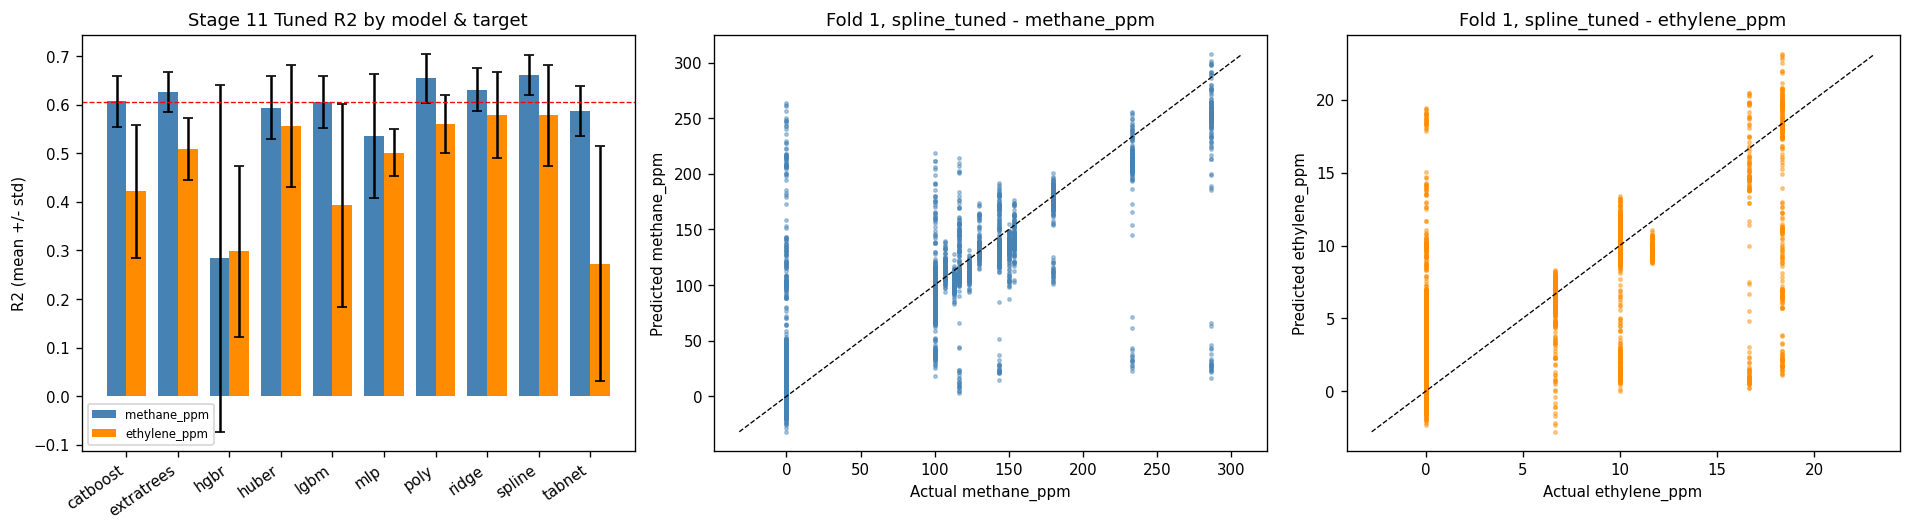

Saved: 11_tuning_optimization.png (best tuned: spline_tuned)


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = {'methane_ppm': 'steelblue', 'ethylene_ppm': 'darkorange'}

ax = axes[0]
tuned_models = sorted(tuned_long['model'].unique())
x = np.arange(len(tuned_models))
w = 0.38
for offset, target in zip((-w/2, w/2), TARGETS):
    means = [tuned_long[(tuned_long['model']==m) &
             (tuned_long['target']==target)]['r2'].mean()
             for m in tuned_models]
    stds  = [tuned_long[(tuned_long['model']==m) &
             (tuned_long['target']==target)]['r2'].std()
             for m in tuned_models]
    ax.bar(x + offset, means, w, yerr=stds, capsize=3,
           label=target, color=colors[target])
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_tuned', '') for m in tuned_models],
                   rotation=35, ha='right')
ax.set_ylabel('R2 (mean +/- std)')
ax.set_title('Stage 11 Tuned R2 by model & target')
ax.legend(fontsize=7)
ax.axhline(0.605, color='red', ls='--', lw=0.8)

best_tuned = tuned_long.groupby('model')['r2'].mean().idxmax()
if best_tuned in fold1_preds:
    y_va, y_pred = fold1_preds[best_tuned]
    n_plot = min(5000, len(y_va))
    samp = np.random.default_rng(SEED).choice(len(y_va), n_plot, replace=False)
    for ax, t_idx, target in zip(axes[1:], (0, 1), TARGETS):
        a = y_va[samp, t_idx]; p = y_pred[samp, t_idx]
        ax.scatter(a, p, s=4, alpha=0.4, color=colors[target])
        lo = float(min(a.min(), p.min()))
        hi = float(max(a.max(), p.max()))
        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
        ax.set_xlabel(f'Actual {target}')
        ax.set_ylabel(f'Predicted {target}')
        ax.set_title(f'Fold 1, {best_tuned} - {target}')

plt.tight_layout()
plt.savefig(FIG_DIR / '11_tuning_optimization.png', bbox_inches='tight')
plt.show()
print(f'Saved: 11_tuning_optimization.png (best tuned: {best_tuned})')

In [17]:
def df_to_md(t):
    header = '| ' + ' | '.join(str(c) for c in t.columns) + ' |'
    sep    = '| ' + ' | '.join(['---'] * len(t.columns)) + ' |'
    rows   = ['| ' + ' | '.join(str(v) for v in row) + ' |'
              for row in t.itertuples(index=False)]
    return '\n'.join([header, sep, *rows])

tuned_ranking = (tuned_long.groupby('model')[['mae', 'rmse', 'r2']]
                 .mean().round(4).reset_index()
                 .sort_values('r2', ascending=False))
best_model = tuned_ranking.iloc[0]['model']

cfg_lines = []
for _, row in tuned_ranking.iterrows():
    name = row['model']
    cfg = best_configs.get(name, {})
    cfg_lines.append(f'| {name} | {cfg} | {row["r2"]:.4f} |')

lines = [
    '# 11 - Tuning & Optimization',
    '',
    '**Date:** 2026-05-24',
    f'**Dataset:** {DATA_PATH.as_posix()}',
    f'**Splits artifact:** {SPLITS_PATH.as_posix()}',
    f'**Subset artifact:** {SUBSET_PATH.as_posix()}',
    '',
    '---',
    '',
    '## Protocol',
    '- Same 5-fold rolling temporal validation as stages 06-10.',
    '- Training = `train_range ∩ fair_subset` (~395k rows). Val = full val slice.',
    '- Fresh `RobustScaler` per fold.',
    '- Early stopping (boosted/neural): last 15% of training set as internal eval.',
    '- Best config per model: highest mean R2 pooled across folds and targets.',
    f'- Total configs evaluated: {len(search_log)}.',
    '',
    '## Models Tuned',
    '- **Pass A (fast):** Ridge, Polynomial, Spline, Huber, ExtraTrees.',
    '- **Pass B (expensive):** LightGBM, CatBoost, HistGradientBoosting, TabNet, MLP.',
    '',
    '## Ranking (tuned models, mean across folds & targets)',
    '',
    df_to_md(tuned_ranking),
    '',
    f'**Best tuned model:** `{best_model}`',
    '',
    '## Best Hyperparameters',
    '',
    '| model | config | R2 |',
    '| --- | --- | --- |',
    *cfg_lines,
    '',
    '## Summary (mean +/- std across 5 folds, per target)',
    '',
    df_to_md(tuned_summary),
    '',
    '## Artifacts',
    f'- Per-fold metrics: `{(TABLES_DIR / "11_tuning_metrics_long.parquet").as_posix()}`',
    f'- Summary metrics: `{(TABLES_DIR / "11_tuning_metrics_summary.parquet").as_posix()}`',
    f'- Search log: `{(TABLES_DIR / "11_tuning_search_log.parquet").as_posix()}`',
    f'- Fitted models: `{MODEL_DIR.as_posix()}/fold_{{k}}_{{name}}.joblib`',
    f'- Figure: `{(FIG_DIR / "11_tuning_optimization.png").as_posix()}`',
    '',
    '## Next step',
    'Stage 12: creative prototype model or final reporting.',
]

MEMO_PATH.write_text('\n'.join(lines), encoding='utf-8')
print(f'Memo saved to {MEMO_PATH}')

Memo saved to ..\results\memos\11_tuning_optimization.md
